c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


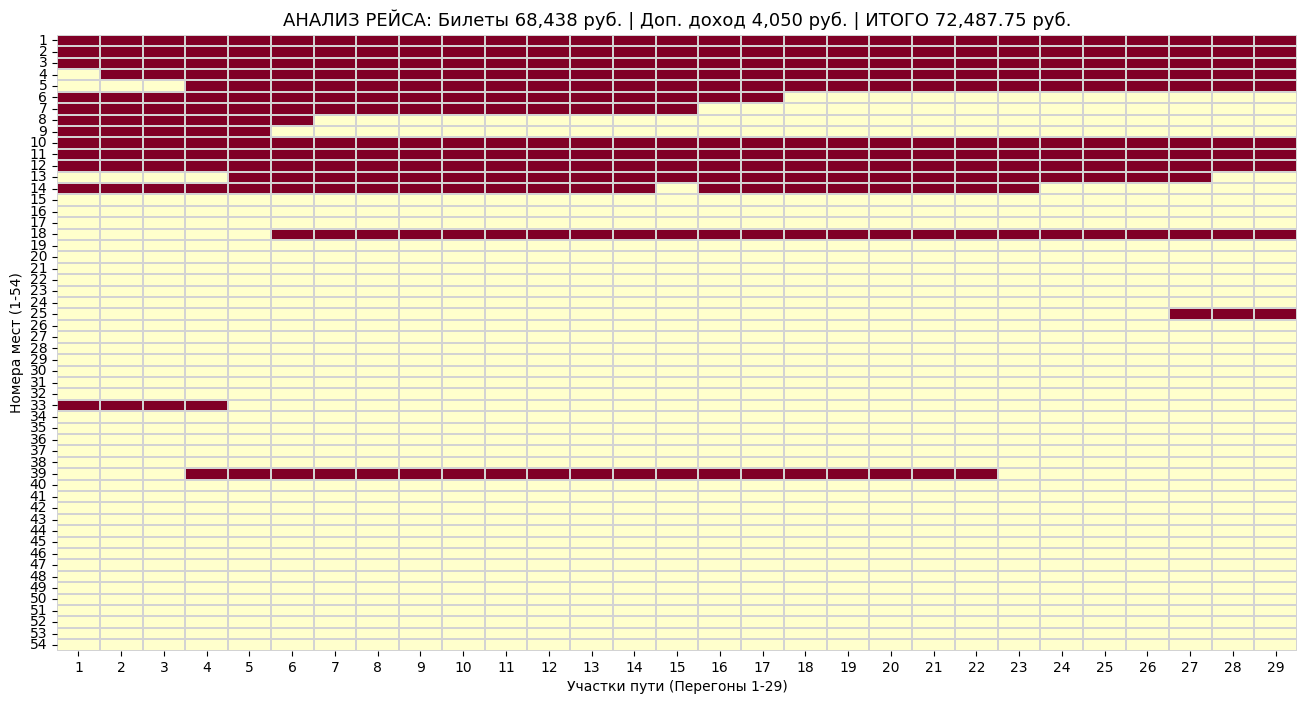

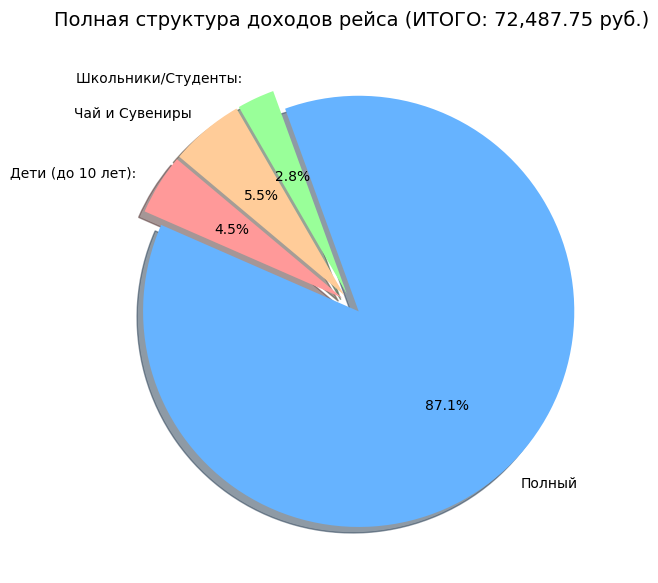

--- АНАЛИТИКА ПОЛНОСТЬЮ СИНХРОНИЗИРОВАНА ---


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ЗАГРУЗКА И ОЧИСТКА
file_path = r'D:\GitHab\Projects\railway-analysis\RZD_Wagon_Analysis.xlsx'
df_raw = pd.read_excel(file_path, sheet_name='Продажи')

# Очищаем заголовки и убираем лишнее (строку Итого и дубликаты)
df_raw.columns = df_raw.columns.str.strip()
df_clean = df_raw.dropna(subset=['Место', 'Индекс ОТ']).copy()
df_clean = df_clean.drop_duplicates(subset=['Место', 'Индекс ОТ', 'Индекс ДО', 'Цена, ₽'])

# Исправляем отрицательные цены (младенцы)
df_clean.loc[df_clean['Цена, ₽'] < 0, 'Цена, ₽'] = 0

# 2. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ (Твои точные цифры)
ticket_rev = 68437.75
extra_rev = 4050.00
total_all = ticket_rev + extra_rev

# 3. ПОДГОТОВКА МАТРИЦЫ (54 места на 29 перегонов)
matrix_auto = np.zeros((54, 29))
for index, row in df_clean.iterrows():
    try:
        seat, start, end = int(row['Место'])-1, int(row['Индекс ОТ'])-1, int(row['Индекс ДО'])-1
        if 0 <= seat < 54 and 0 <= start < 29:
            matrix_auto[seat, start:end] = 1
    except: continue

# 4. ВИЗУАЛИЗАЦИЯ: HEATMAP (Где люди?)
plt.figure(figsize=(16, 8))
sns.heatmap(matrix_auto, cmap="YlOrRd", vmin=0, vmax=1, linewidths=0.1, linecolor='lightgray', cbar=False,
            xticklabels=range(1, 30), yticklabels=range(1, 55))
plt.title(f"АНАЛИЗ РЕЙСА: Билеты {ticket_rev:,.0f} руб. | Доп. доход {extra_rev:,.0f} руб. | ИТОГО {total_all:,.2f} руб.", fontsize=13)
plt.xlabel("Участки пути (Перегоны 1-29)")
plt.ylabel("Номера мест (1-54)")
plt.show()

# 5. ВИЗУАЛИЗАЦИЯ: ПИРОГ (Откуда деньги?)
# Группируем выручку по билетам и добавляем чай
ticket_revenue_split = df_clean.groupby('Тип пассажира')['Цена, ₽'].sum()
ticket_revenue_split = ticket_revenue_split[ticket_revenue_split > 0]
extra_data = pd.Series({'Чай и Сувениры': extra_rev})
full_revenue_data = pd.concat([ticket_revenue_split, extra_data])

plt.figure(figsize=(10, 7))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0', '#ffb3e6']
full_revenue_data.plot(kind='pie', autopct='%1.1f%%', startangle=140, shadow=True, 
                      colors=colors[:len(full_revenue_data)], explode=[0.05] * len(full_revenue_data))
plt.title(f"Полная структура доходов рейса (ИТОГО: {total_all:,.2f} руб.)", fontsize=14)
plt.ylabel("") 
plt.show()

print(f"--- АНАЛИТИКА ПОЛНОСТЬЮ СИНХРОНИЗИРОВАНА ---")

